In [1]:
%reload_ext autoreload
%autoreload 2

# Imports

In [2]:
from kret_notebook import *  # NOTE import first
from kret_lgbm._core.lgbm_nb_imports import *
from kret_lightning._core.lightning_nb_imports import *
from kret_matplotlib._core.mpl_nb_imports import *
from kret_np_pd._core.np_pd_nb_imports import *
from kret_optuna._core.optuna_nb_imports import *
from kret_polars._core.polars_nb_imports import *
from kret_rosetta._core.rosetta_nb_imports import *
from kret_sklearn._core.sklearn_nb_imports import *
from kret_torch_utils._core.torch_nb_imports import *
from kret_tqdm._core.tqdm_nb_imports import *
from kret_type_hints._core.types_nb_imports import *
from kret_utils._core.utils_nb_imports import *

# from kret_wandb._core.wandb_nb_imports import *  # NOTE this is slow to import

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
[kret_lgbm._core.lgbm_nb_imports] Imported kret_lgbm._core.lgbm_nb_imports in 1.9060 seconds
[kret_lightning._core.lightning_nb_imports] Imported kret_lightning._core.lightning_nb_imports in 4.1727 seconds
[kret_matplotlib._core.mpl_nb_imports] Imported kret_matplotlib._core.mpl_nb_imports in 0.3753 seconds
[kret_np_pd._core.np_pd_nb_imports] Imported kret_np_pd._core.np_pd_nb_imports in 0.0005 seconds
[kret_optuna._core.optuna_nb_imports] Imported kret_optuna._core.optuna_nb_imports in 0.0008 seconds
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.0000 seconds
[kret_rosetta._core.rosetta_nb_imports] Imported kret_rosetta._core.rosetta_nb_imports in 0.0000 seconds
[kret_sklearn._core.sklearn_nb_imports] Imported kret_sklearn._core.sklearn_nb_imports in 0.0844 seconds
[kret_torch_utils._core.torch_nb_imports] Imported kret_torch_utils._core.torch_nb_imports i

In [3]:
from nba_timeout_impact.nb_imports import *

# TV / mandatory timeout study

Two questions:

1. **Visual evidence** that mandatory timeouts in cdnnba (post-2017) already exist as ordinary `subType="full"` rows, clustering at the rulebook trigger marks.
2. **Reclassification** of each timeout row's role (slot_K_mandatory / slot_K_absorbed / discretionary / challenge), tested on the v3 labeled era (1998-2016) against ground-truth `Official` / `Official TV` subTypes.

# Load data

In [4]:
from nba_timeout_impact.datasets.memo_nbastatsv3 import NBAMemoDF
from nba_timeout_impact.datasets.memo_cdnnba_pl import CDNNBAMemoPL
from nba_timeout_impact.data_pipes.tv_timeout_injection import TVTimeoutValidation

memo_v3 = NBAMemoDF.load_all()  # nbastatsv3 + nbastats v2 (~1s)
memo_cdn = CDNNBAMemoPL.load_all()  # cdnnba post-2017 (~3s)

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 74 cols, 1 warnings).
Validating boxscores data (Polars)...
  Passed (217,190 rows, 36 cols).
Validating player_advanced_stats data (Polars)...
  Passed (3,400 rows, 119 cols).
Validating player_season_stats data (Polars)...
  Passed (5,174 rows, 31 cols).
Validating rotations data (Polars)...
  Passed (1,905,583 rows, 16 cols, 1 warnings).
Validating stints data (Polars)...
  Passed (2,145,106 rows, 14 cols, 1 warnings).


# Part 1 — Density of cdnnba timeouts by clock bin

The cdnnba memo has a parameterized `sr_bin(width)` column. Plot the
density of `full` and `challenge` timeouts at 15s / 30s / 60s resolutions
to see where they cluster relative to the rulebook trigger marks (7:00
and 3:00 = sr=420 and sr=180).

Calculating bin_sr(15,)
Calculating bin_sr(30,)
Calculating bin_sr(60,)


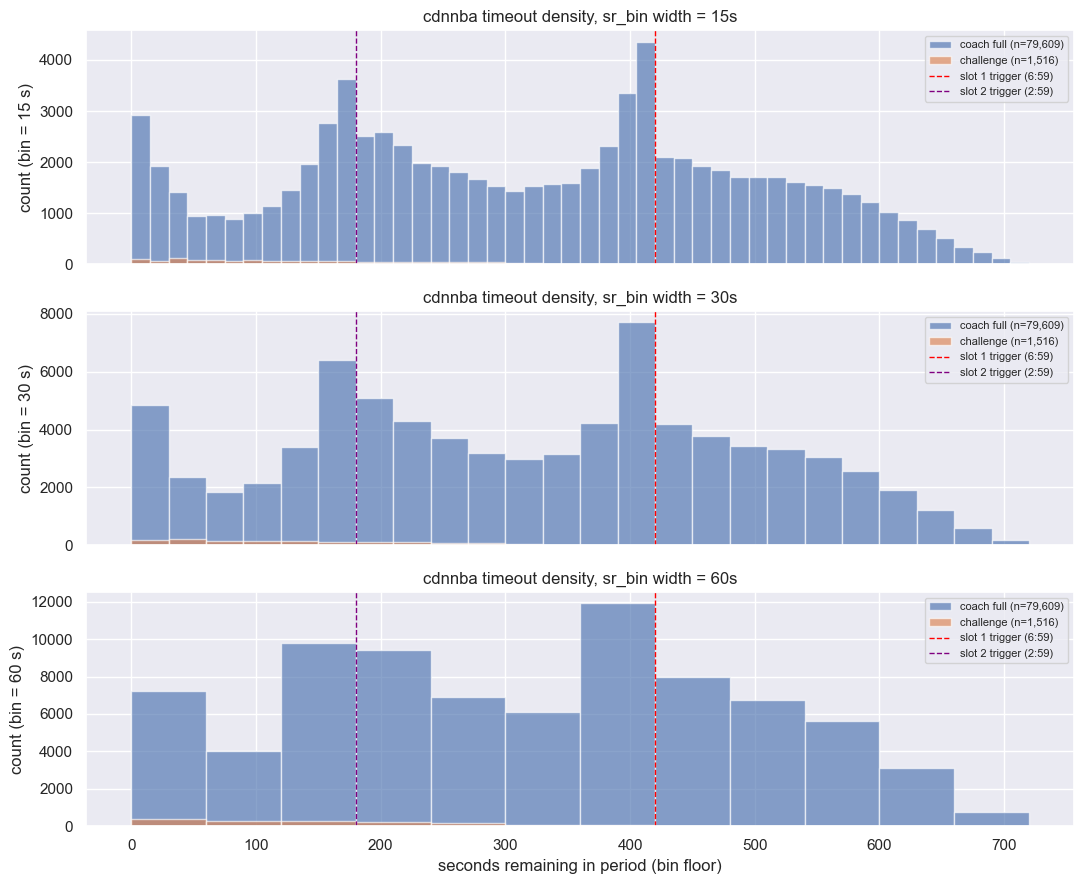

In [5]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

df = pl.DataFrame._from_pydf(memo_cdn.cdnnba._df)
df = df.filter((pl.col("actionType") == "timeout") & pl.col("period").is_in([1, 2, 3, 4]))

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, width in zip(axes, [15, 30, 60]):
    binned = df.with_columns(memo_cdn.bin_sr(width).gather(df["orderNumber"] - df["orderNumber"]))  # dummy alignment
    # simpler: just compute bins directly here
    bins = (df["seconds_remaining"] // width * width).cast(pl.Int32)
    df2 = df.with_columns(bins.alias("sr_bin"))
    for sub, color, label in [("full", "C0", "coach full"), ("challenge", "C1", "challenge")]:
        vals = df2.filter(pl.col("subType") == sub)["sr_bin"].to_numpy()
        if len(vals) == 0:
            continue
        ax.hist(
            vals, bins=np.arange(0, 720 + width, width), alpha=0.65, label=f"{label} (n={len(vals):,})", color=color
        )
    ax.axvline(420, color="red", linestyle="--", linewidth=1, label="slot 1 trigger (6:59)")
    ax.axvline(180, color="purple", linestyle="--", linewidth=1, label="slot 2 trigger (2:59)")
    ax.set_ylabel(f"count (bin = {width} s)")
    ax.set_title(f"cdnnba timeout density, sr_bin width = {width}s")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("seconds remaining in period (bin floor)")
plt.tight_layout()
plt.show()

The bimodal peaks just inside the 7:00 and 3:00 marks confirm mandatories
are already present in cdnnba as ordinary `full` timeouts — no injection
needed. The classifier's job is to label *which* of these are
mandatory-driven vs discretionary.

# Part 2 — Reclassification on v3 labeled era

Apply `TVTimeoutValidation.classify_timeouts` to v3 PBP **restricted to 2013-2016** (last 4 years of the labeled era) and
compare predictions (`slot_K_mandatory`) against v3's explicit `Official`
/ `Official TV` ground-truth labels. The classifier sees only `(gameId,
period, seconds_remaining, actionType, order)` — never `subType` (no
cheating).

Filtering to 2013-2016 gives us a cleaner pre-2017 sample (consistent
broadcast/rule conventions, modern data quality) without leaking any
post-2017 rule changes.


## Headline metrics — both pre-2017 modes (seasons 2013-2016)


In [6]:
import pandas as pd

SEASONS = (2013, 2016)
rows = []
for mode in ["independent", "cascading"]:
    for match_mode in ("row", "fuzzy"):
        r = TVTimeoutValidation.validate_against_v3(
            memo_v3,
            seasons=SEASONS,
            pre_2017_mode=mode,
            match_mode=match_mode,
            tolerance_s=60,
        )
        rows.append(
            {
                "pre_2017_mode": mode,
                "match_mode": match_mode,
                "TP": r.tp,
                "FP": r.fp,
                "FN": r.fn,
                "P": round(r.precision, 3),
                "R": round(r.recall, 3),
                "F1": round(r.f1, 3),
            }
        )
pd.DataFrame(rows)

,pre_2017_mode,match_mode,TP,FP,FN,P,R,F1
0,independent,row,6362,8815,1929,0.419,0.767,0.542
1,independent,fuzzy,6637,8540,1654,0.437,0.801,0.566
2,cascading,row,5397,2922,2894,0.649,0.651,0.650
3,cascading,fuzzy,5564,2755,2727,0.669,0.671,0.670


## Per-period breakdown (best mode)

In [7]:
r = TVTimeoutValidation.validate_against_v3(memo_v3, seasons=SEASONS, pre_2017_mode="cascading", match_mode="row")
print(f"per-period row-by-row (seasons {SEASONS}, cascading):")
print(r.per_period.to_string(index=False))

per-period row-by-row (seasons (2013, 2016), cascading):
 period   TP   FP   FN  precision   recall       f1
      1    0    0    1   0.000000 0.000000 0.000000
      2 2768 1444 1624   0.657170 0.630237 0.643422
      3    0    0    3   0.000000 0.000000 0.000000
      4 2629 1478 1266   0.640127 0.674968 0.657086
      5    0    0    0   0.000000 0.000000 0.000000
      6    0    0    0   0.000000 0.000000 0.000000
      7    0    0    0   0.000000 0.000000 0.000000
      8    0    0    0   0.000000 0.000000 0.000000


## Confusion matrix: where the classifier disagrees with v3

Rows are v3 ground-truth `subType`; columns are predicted `timeout_role`.
Strong diagonal would mean perfect classification. Off-diagonal cells
tell us where the rulebook walk diverges from v3 labels.

In [8]:
confusion = TVTimeoutValidation.confusion_matrix_v3(memo_v3, seasons=SEASONS, pre_2017_mode="cascading")

In [9]:
confusion

predicted_role,discretionary,slot_1_absorbed,slot_1_mandatory,slot_2_absorbed,slot_2_mandatory,slot_3_absorbed,slot_3_mandatory,TOTAL
gt_subType,,,,,,,,
,10,0,3,1,1,0,0,15
Official,1957,0,4052,464,880,473,465,8291
Regular,40367,3334,2036,1779,493,1137,184,49330
Short,11286,178,8,313,100,293,97,12275
TOTAL,53620,3512,6099,2557,1474,1903,746,69911


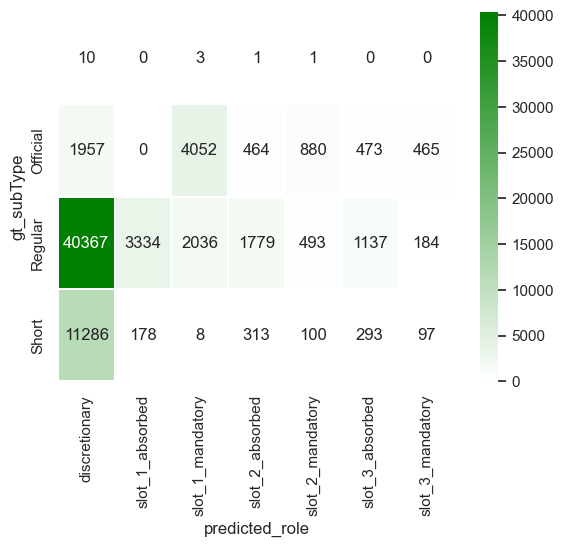

In [10]:
UKS_MPL.heatmap_df(confusion.drop(index="TOTAL", columns="TOTAL"))

## Where the classifier works and doesn't

**Working well**:
- Most `Regular` (coach voluntary) TOs are correctly tagged as `discretionary` or appropriate `_absorbed` slots.
- ~70 % of `Official` GT rows are correctly predicted as some `slot_K_mandatory`.
- `Coach Challenge` rows are cleanly identified.

**Failure modes**:
- `Official` rows labeled as `discretionary`: a second/third Official in the same (game, period) when our cascading model says only one mandatory fires. This is the strongest evidence that pre-2017 may have allowed *independent* firing — though switching modes only nudges F1 slightly.
- `Official` rows labeled as `slot_K_absorbed`: an earlier coach TO ate the absorption window, so the classifier reasonably tags the next TO as absorbing the next slot — but v3 still labels it `Official`. This suggests v3's `Official` may capture *every* TV-break event independent of absorption logic.
- `Regular` rows labeled as `slot_K_mandatory`: false positives when a coach TO happens at or just below a mandatory threshold. The classifier can't tell from position alone whether this was voluntary or auto-charged.
- `Short` rows mostly land in `discretionary` or `_absorbed`. `Short` (20-second timeouts) were a separate event class pre-2017 — they probably shouldn't be candidates for mandatory roles at all. **Possible fix**: drop `Short` from the candidate set before running the rulebook walk.

## Sanity: cdnnba (post-2017) reclassification (no GT, just role distribution)

# Sandbox

In [103]:
# Precompute classifier outputs once: ValidationResult + classified row DataFrame.
# The classifier walks each period sequentially (row by row); each TO claims at most
# one slot. ``mandatory_tolerance_s`` controls how far below a slot's trigger a TO
# is still tagged as mandatory firing (default 60s).
PRE_MODE = "cascading"
MAND_TOL = 60

r_v3 = TVTimeoutValidation.validate_against_v3(
    memo_v3,
    seasons=SEASONS,
    pre_2017_mode=PRE_MODE,
    match_mode="row",
    mandatory_tolerance_s=MAND_TOL,
)

v3_pl = TVTimeoutValidation._prep_v3(memo_v3, SEASONS)
classified_v3 = TVTimeoutValidation.classify_timeouts(
    v3_pl,
    source="v3",
    seasons=SEASONS,
    pre_2017_mode=PRE_MODE,
    mandatory_tolerance_s=MAND_TOL,
)

In [120]:
v3_pl.shape, classified_v3.shape

((2505353, 8), (2505353, 9))

In [ ]:
v3_pl.shape[0] == classified_v3.shape[0]

True

In [104]:
UKS_NP_PD.dtt([classified_v3, classified_v3["timeout_role"].value_counts(), memo_v3.data], how="head", n=8)

gameId 
 actionNumber 
 period 
 actionType 
 subType 
 seconds_remaining 
 season 
 season_type 
 timeout_role 
 
 
 
 int64 
 int64 
 int64 
 str 
 str 
 float64 
 int64 
 str 
 str 
 
 
 
 
 0 
 21300001 
 0 
 1 
 period 
 start 
 720.000 
 2013 
 rg 
 
 
 
 1 
 21300001 
 1 
 1 
 Jump Ball 
 NaN 
 720.000 
 2013 
 rg 
 
 
 
 2 
 21300001 
 2 
 1 
 Missed Shot 
 Jump Shot 
 699.000 
 2013 
 rg 
 
 
 
 3 
 21300001 
 3 
 1 
 Rebound 
 Unknown 
 699.000 
 2013 
 rg 
 
 
 
 4 
 21300001 
 4 
 1 
 Foul 
 Loose Ball 
 699.000 
 2013 
 rg 
 
 
 
 5 
 21300001 
 5 
 1 
 Made Shot 
 Pullup Jump shot 
 690.000 
 2013 
 rg 
 
 
 
 6 
 21300001 
 6 
 1 
 Missed Shot 
 Jump Shot 
 675.000 
 2013 
 rg 
 
 
 
 7 
 21300001 
 7 
 1 
 Rebound 
 Unknown 
 674.000 
 2013 
 rg 
 
 
 
 
 
 
 
 timeout_role 
 count 
 
 
 
 str 
 uint32 
 
 
 
 
 0 
 slot_2_absorbed 
 2578 
 
 
 1 
 slot_2_mandatory 
 1458 
 
 
 2 
 slot_1_absorbed 
 3515 
 
 
 3 
 slot_1_mandatory 
 6090 
 
 
 4 
 
 2435442 
 
 
 5 
 discretionary 
 53597 
 
 
 6 
 slot_3_absorbed 
 1931 
 
 
 7 
 slot_3_mandatory 
 742 
 
 
 
 
 
 
 actionNumber 
 clock 
 period 
 teamId 
 teamTricode 
 personId 
 playerName 
 playerNameI 
 xLegacy 
 yLegacy 
 shotDistance 
 shotResult 
 isFieldGoal 
 scoreHome 
 scoreAway 
 pointsTotal 
 location 
 description 
 actionType 
 subType 
 videoAvailable 
 actionId 
 gameId 
 season 
 season_type 
 seconds_remaining 
 seconds_elapsed 
 game_seconds_elapsed 
 pc_seconds 
 IsPlayoff 
 shotValue 
 game_date 
 game_date_ffill 
 
 
 
 int64 
 str 
 int64 
 int64 
 str 
 int64 
 str 
 str 
 int64 
 int64 
 int64 
 str 
 int64 
 float64 
 float64 
 int64 
 str 
 str 
 str 
 str 
 int64 
 int64 
 int64 
 int64 
 str 
 float64 
 float64 
 float64 
 int32 
 bool 
 float64 
 datetime64[ns] 
 datetime64[ns] 
 
 
 
 
 0 
 0 
 PT12M00.00S 
 1 
 0 
 NaN 
 0 
 NaN 
 NaN 
 0 
 0 
 0 
 NaN 
 0 
 0.000 
 0.000 
 0 
 NaN 
 Start of 1st Period (12:13 PM EST) 
 period 
 start 
 0 
 1 
 20000001 
 2000 
 rg 
 720.000 
 0.000 
 0.000 
 720 
 False 
 0.000 
 NaT 
 NaT 
 
 
 1 
 1 
 PT12M00.00S 
 1 
 1610612752 
 NYK 
 948 
 Camby 
 M. Camby 
 0 
 0 
 0 
 NaN 
 0 
 0.000 
 0.000 
 0 
 h 
 Jump Ball Camby vs. Ratliff: Tip to Houston 
 Jump Ball 
 NaN 
 0 
 2 
 20000001 
 2000 
 rg 
 720.000 
 0.000 
 0.000 
 720 
 False 
 0.000 
 NaT 
 NaT 
 
 
 2 
 2 
 PT11M41.00S 
 1 
 1610612752 
 NYK 
 84 
 Sprewell 
 L. Sprewell 
 -58 
 28 
 6 
 Missed 
 1 
 0.000 
 0.000 
 0 
 h 
 MISS Sprewell 6' Jump Shot 
 Missed Shot 
 Jump Shot 
 0 
 3 
 20000001 
 2000 
 rg 
 701.000 
 19.000 
 19.000 
 701 
 False 
 0.000 
 NaT 
 NaT 
 
 
 3 
 2 
 PT11M41.00S 
 1 
 1610612755 
 PHI 
 689 
 Ratliff 
 T. Ratliff 
 0 
 0 
 0 
 NaN 
 0 
 0.000 
 0.000 
 0 
 v 
 Ratliff BLOCK (1 BLK) 
 NaN 
 NaN 
 0 
 4 
 20000001 
 2000 
 rg 
 701.000 
 19.000 
 19.000 
 701 
 False 
 0.000 
 NaT 
 NaT 
 
 
 4 
 3 
 PT11M40.00S 
 1 
 0 
 NaN 
 1610612755 
 NaN 
 NaN 
 0 
 0 
 0 
 NaN 
 0 
 0.000 
 0.000 
 0 
 v 
 76ers Rebound 
 Rebound 
 Unknown 
 0 
 5 
 20000001 
 2000 
 rg 
 700.000 
 20.000 
 20.000 
 700 
 False 
 0.000 
 NaT 
 NaT 
 
 
 5 
 4 
 PT11M29.00S 
 1 
 1610612752 
 NYK 
 948 
 Camby 
 M. Camby 
 0 
 0 
 0 
 NaN 
 0 
 0.000 
 0.000 
 0 
 h 
 Camby S.FOUL (P1.T1) 
 Foul 
 Shooting 
 0 
 6 
 20000001 
 2000 
 rg 
 689.000 
 31.000 
 31.000 
 689 
 False 
 0.000 
 NaT 
 NaT 
 
 
 6 
 5 
 PT11M29.00S 
 1 
 1610612755 
 PHI 
 689 
 Ratliff 
 T. Ratliff 
 0 
 0 
 0 
 NaN 
 0 
 0.000 
 1.000 
 1 
 v 
 Ratliff Free Throw 1 of 2 (1 PTS) 
 Free Throw 
 Free Throw 1 of 2 
 0 
 7 
 20000001 
 2000 
 rg 
 689.000 
 31.000 
 31.000 
 689 
 False 
 0.000 
 NaT 
 NaT 
 
 
 7 
 6 
 PT11M29.00S 
 1 
 1610612755 
 PHI 
 689 
 Ratliff 
 T. Ratliff 
 0 
 0 
 0 
 NaN 
 0 
 0.000 
 0.000 
 0 
 v 
 MISS Ratliff Free Throw 2 of 2 
 Free Throw 
 Free Throw 2 of 2 
 0 
 8 
 20000001 
 2000 
 rg 
 689.000 
 31.000 
 31.000 
 689 
 False 
 0.000 
 NaT 
 NaT

In [105]:
# Ground-truth mandatories: Official / Official TV, restricted to Q2/Q4
gt_v3 = classified_v3.filter(
    (pl.col("actionType").cast(pl.String).str.strip_chars() == "Timeout")
    & pl.col("subType").cast(pl.String).str.strip_chars().is_in(["Official", "Official TV"])
    # & pl.col("period").is_in([2, 4])
)
# Predicted mandatories from the rulebook walk
pred_v3 = classified_v3.filter(
    pl.col("timeout_role").str.contains("_mandatory")
    # & pl.col("period").is_in([2, 4])
)

gt_sr = gt_v3["seconds_remaining"].to_numpy()
pred_sr = pred_v3["seconds_remaining"].to_numpy()

In [106]:
UKS_NP_PD.dtt([gt_v3, pred_v3], how="head", n=8, show_dims=True)

gameId 
 actionNumber 
 period 
 actionType 
 subType 
 seconds_remaining 
 season 
 season_type 
 timeout_role 
 
 
 
 int64 
 int64 
 int64 
 str 
 str 
 float64 
 int64 
 str 
 str 
 
 
 
 
 0 
 21300001 
 209 
 2 
 Timeout 
 Official 
 156.000 
 2013 
 rg 
 discretionary 
 
 
 1 
 21300001 
 500 
 4 
 Timeout 
 Official 
 130.000 
 2013 
 rg 
 discretionary 
 
 
 2 
 21300002 
 155 
 2 
 Timeout 
 Official 
 532.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 3 
 21300002 
 457 
 4 
 Timeout 
 Official 
 532.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 4 
 21300003 
 181 
 2 
 Timeout 
 Official 
 531.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 5 
 21300003 
 483 
 4 
 Timeout 
 Official 
 516.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 6 
 21300004 
 203 
 2 
 Timeout 
 Official 
 486.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 7 
 21300005 
 191 
 2 
 Timeout 
 Official 
 155.000 
 2013 
 rg 
 slot_3_mandatory 
 
 
 
 Showing 8 of 8,291 rows × 9 columns 
 
 
 
 
 
 gameId 
 actionNumber 
 period 
 actionType 
 subType 
 seconds_remaining 
 season 
 season_type 
 timeout_role 
 
 
 
 int64 
 int64 
 int64 
 str 
 str 
 float64 
 int64 
 str 
 str 
 
 
 
 
 0 
 21300002 
 155 
 2 
 Timeout 
 Official 
 532.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 1 
 21300002 
 457 
 4 
 Timeout 
 Official 
 532.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 2 
 21300003 
 181 
 2 
 Timeout 
 Official 
 531.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 3 
 21300003 
 483 
 4 
 Timeout 
 Official 
 516.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 4 
 21300004 
 203 
 2 
 Timeout 
 Official 
 486.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 5 
 21300005 
 191 
 2 
 Timeout 
 Official 
 155.000 
 2013 
 rg 
 slot_3_mandatory 
 
 
 6 
 21300005 
 379 
 4 
 Timeout 
 Official 
 530.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 7 
 21300006 
 172 
 2 
 Timeout 
 Official 
 494.000 
 2013 
 rg 
 slot_1_mandatory 
 
 
 
 Showing 8 of 8,290 rows × 9 columns

## v3 mandatory clustering — GT vs predicted overlap

Two-color overlap; metrics box uses **greedy match (60 s tol)**.


In [119]:
# fig, axes = TimeoutInjectionPlots.plot_gt_vs_predicted_overlap(r_v3, classified_v3, widths=(8, 15))
# fig

## v3 mandatory clustering — stacked TP / FP / FN

Each timeout row in Q2/Q4 is classified row-by-row:

- **TP** — predicted mandatory AND v3 `subType` is Official / Official TV
- **FP** — predicted mandatory but v3 didn't tag it as Official
- **FN** — v3 tagged Official but classifier said discretionary / absorbed

Bars stack (non-overlapping), so each (sr-bin, width) shows the full population.


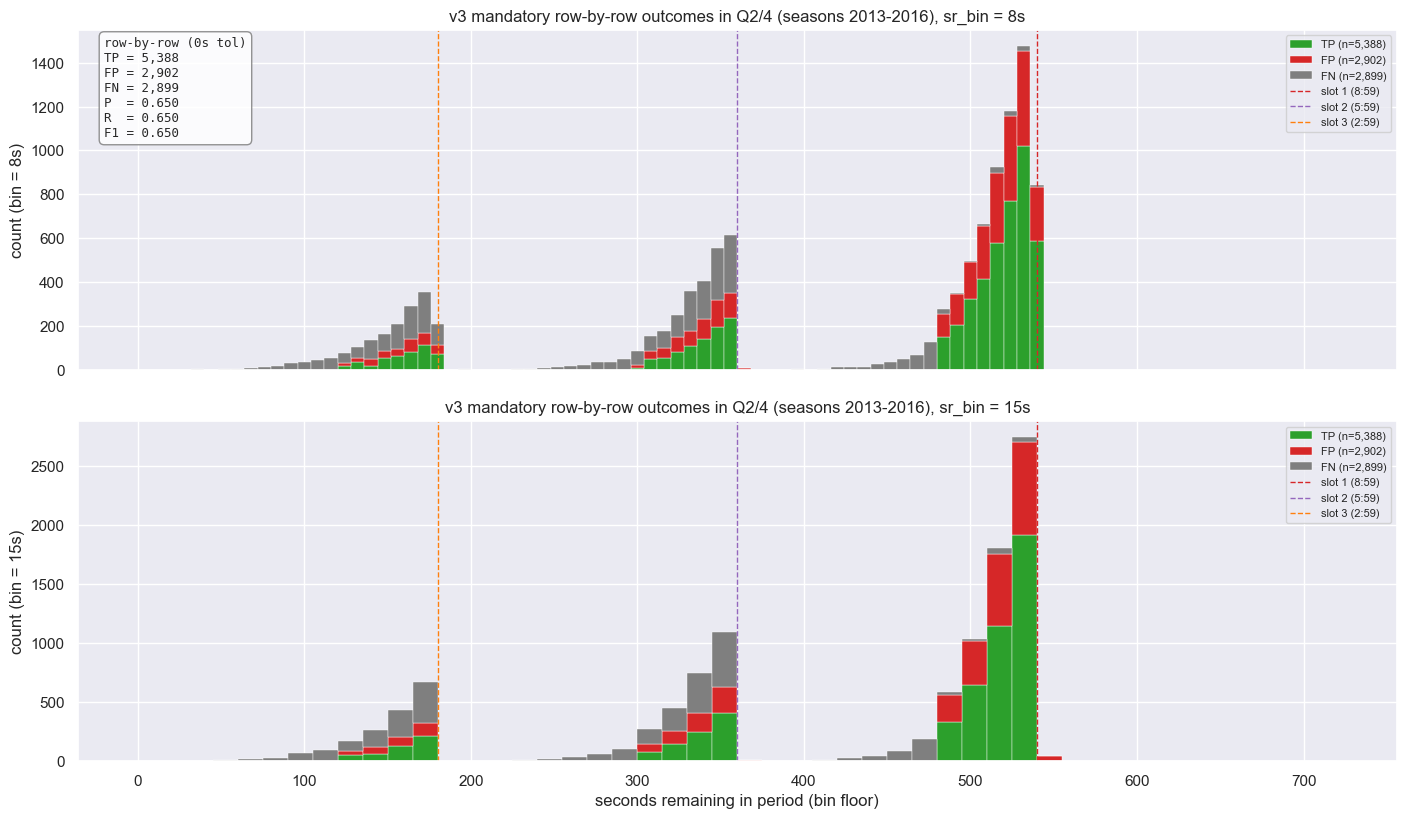

In [108]:
fig, axes, m = TimeoutInjectionPlots.plot_stacked_tp_fp_fn(r_v3, classified_v3, widths=(8, 15))
fig

In [ ]:
raise ValueError("Stop here")

# Sandbox

In [109]:
def classify_timeouts(
    df: pl.DataFrame | pd.DataFrame,
    source: t.Literal["v3", "cdnnba"],
    seasons: tuple[int, int] | None = None,
):
    cfg = TVTimeoutValidation.get_source_config(source)
    timeout_action = cfg["timeout_action"]
    challenge_subs = set(cfg["challenge_subtypes"])
    order_col = cfg["order_col"]

    df_pd = df.to_pandas() if isinstance(df, pl.DataFrame) else df

    if seasons is not None and "season" in df_pd.columns:
        lo, hi = seasons
        # The fix for your specific code
        df_pd = df_pd[df_pd["season"].between(lo, hi)]

    df_pd["f_isTimeout"] = df_pd["actionType"].str.strip() == timeout_action
    df_pd["f_timeLT_6_59"] = df_pd["seconds_remaining"] < 6 * 60 + 59
    df_pd["f_timeLT_2_59"] = df_pd["seconds_remaining"] < 2 * 60 + 59

    df_pd["actionType"] = df_pd["actionType"].str.strip()
    df_pd["subType"] = df_pd["subType"].str.strip()

    # Create a list of tuples, then convert to categorical
    df_pd["GamePeriodCat"] = pd.Categorical(list(zip(df_pd["gameId"], df_pd["period"])), ordered=True)
    df_pd["cumTimeoutsInPeriod"] = df_pd.groupby("GamePeriodCat", observed=True)["f_isTimeout"].cumsum()
    # Check if it's a timeout, if it's the first one (cum == 1), and if it hits the time flag
    # 1. Define the specific conditions
    cond_6_59 = df_pd["f_isTimeout"] & df_pd["f_timeLT_6_59"]
    cond_2_59 = df_pd["f_isTimeout"] & df_pd["f_timeLT_2_59"]

    # 2. Use groupby + cumsum to flag only the first occurrence per group
    # We check where cumsum == 1 AND the condition itself is True
    df_pd["f_firstTimeoutLT_6_59"] = (
        cond_6_59.groupby(df_pd["GamePeriodCat"], observed=True).cumsum() == 1
    ) & cond_6_59
    df_pd["f_firstTimeoutLT_2_59"] = (
        cond_2_59.groupby(df_pd["GamePeriodCat"], observed=True).cumsum() == 1
    ) & cond_2_59

    df_pd["MandatoryTimeout"] = (df_pd["f_firstTimeoutLT_6_59"] & df_pd["cumTimeoutsInPeriod"] == 1) | (
        df_pd["f_firstTimeoutLT_2_59"] & df_pd["cumTimeoutsInPeriod"] == 2
    )

    return df_pd, timeout_action, challenge_subs, order_col

In [110]:
df_pl, timeout_action, challenge_subs, order_col = classify_timeouts(v3_pl, source="v3", seasons=SEASONS)

In [111]:
timeout_action, challenge_subs, order_col

('Timeout', {'Coach Challenge'}, 'actionNumber')

In [112]:
UKS_NP_PD.dtt(memo_v3.data)

,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,actionId,gameId,season,season_type,seconds_remaining,seconds_elapsed,game_seconds_elapsed,pc_seconds,IsPlayoff,shotValue,game_date,game_date_ffill
,int64,str,int64,int64,str,int64,str,str,int64,int64,int64,str,int64,float64,float64,int64,str,str,str,str,int64,int64,int64,int64,str,float64,float64,float64,int32,bool,float64,datetime64[ns],datetime64[ns]
45841,83,PT03M45.00S,1,1610612748,MIA,224,Jones,E. Jones,0,0,0,NaN,0,0.000,0.000,0,v,Jones Bad Pass Turnover (P1.T7),Turnover,Bad Pass,0,90,20000094,2000,rg,225.000,495.000,495.000,225,False,0.000,NaT,NaT
1730829,358,PT09M44.00S,4,1610612750,MIN,84,Sprewell,L. Sprewell,0,0,0,NaN,0,0.000,0.000,0,v,Sprewell REBOUND (Off:0 Def:3),Rebound,Unknown,0,347,20300077,2003,rg,584.000,136.000,2296.000,584,False,0.000,NaT,NaT
1818414,244,PT01M31.00S,2,1610612756,PHX,1751,White,J. White,0,0,0,NaN,0,0.000,0.000,0,v,White REBOUND (Off:1 Def:4),Rebound,Unknown,0,254,20300260,2003,rg,91.000,629.000,1349.000,91,False,0.000,NaT,NaT
3447310,216,PT04M52.00S,2,1610612746,LAC,2624,Ross,Q. Ross,169,10,17,Missed,1,NaN,NaN,0,h,MISS Ross 17' Jump Shot,Missed Shot,Jump Shot,0,210,20600039,2006,rg,292.000,428.000,1148.000,292,False,0.000,NaT,NaT
4903774,53,PT03M27.00S,1,1610612755,PHI,2223,Dalembert,S. Dalembert,0,0,0,NaN,0,0.000,0.000,0,v,SUB: Brand FOR Dalembert,Substitution,NaN,0,52,20800659,2008,rg,207.000,513.000,513.000,207,False,0.000,NaT,NaT


In [113]:
game_id = 41500407
f_game_id = df_pl.gameId == game_id

In [114]:
7 * 60 + 59, 2 * 60 + 59

(479, 179)

In [115]:
# UKS_NP_PD.dtt(df_pl,  n=20, how='tail')

In [116]:
UKS_NP_PD.dtt(df_pl, filter=(f_game_id & df_pl["f_isTimeout"]), n=25)

,gameId,actionNumber,period,actionType,subType,seconds_remaining,season,season_type,f_isTimeout,f_timeLT_6_59,f_timeLT_2_59,GamePeriodCat,cumTimeoutsInPeriod,f_firstTimeoutLT_6_59,f_firstTimeoutLT_2_59,MandatoryTimeout
,int64,int64,int64,str,str,float64,int64,str,bool,bool,bool,category,int64,bool,bool,bool
2504927,41500407,39,1,Timeout,Regular,418.000,2015,po,True,True,False,"(41500407, 1)",1,True,False,True
2504957,41500407,68,1,Timeout,Regular,149.000,2015,po,True,True,True,"(41500407, 1)",2,False,True,False
2505033,41500407,149,2,Timeout,Official,504.000,2015,po,True,False,False,"(41500407, 2)",1,False,False,False
2505066,41500407,188,2,Timeout,Regular,343.000,2015,po,True,True,False,"(41500407, 2)",2,True,False,False
2505086,41500407,209,2,Timeout,Short,239.000,2015,po,True,True,False,"(41500407, 2)",3,False,False,False
2505104,41500407,229,2,Timeout,Regular,147.000,2015,po,True,True,True,"(41500407, 2)",4,False,True,False
2505147,41500407,274,3,Timeout,Regular,533.000,2015,po,True,False,False,"(41500407, 3)",1,False,False,False
2505165,41500407,291,3,Timeout,Regular,458.000,2015,po,True,False,False,"(41500407, 3)",2,False,False,False
2505199,41500407,328,3,Timeout,Regular,273.000,2015,po,True,True,False,"(41500407, 3)",3,True,False,True


In [117]:
504 // 60, 504 / 60

(8, 8.4)